# Entropy-Flow

The other two extensions change the selector `u`. This one doesn't touch it
it changes **what scalar gets pulled back**.

The observation it starts from is about the paper's own construction. The soft
adjoint replaces every hard switch with a soft one, backward pass only:

| layer | backward multiplier |
|---|---|
| ReLU / GELU | `Phi(z/tau)` |
| MaxPool | `softmax(window/tau)` |
| attention | `softmax(QK'/tau)` |

Each is **a distribution over which way the switch went**. They exist because
the hard switch destroys the information about how close the decision was
and then the pullback only ever uses the mean. The spread is sitting there
unused.

Important!!

That spread is the gate entropy. Pull *it* back and you get a map of where the
network is undecided, rather than of what supports a class.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings('ignore')
torch.set_num_threads(4)
pd.set_option('display.width', 160)

from spx import load_bundle, load_imagenette
from spx.data import IMAGENETTE_NAMES
from spx.dossier import show_maps, summary_table

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bundle = load_bundle('resnet50', device)

x_np, y_np, _ = load_imagenette(n=4, res=224, seed=0)
X = torch.as_tensor(x_np, device=device)
Y = torch.as_tensor(y_np, device=device)
titles = [IMAGENETTE_NAMES[int(v)] for v in y_np]
titles

['gas pump', 'chain saw', 'gas pump', 'French horn']

## Gate entropy

A ReLU gate is a Bernoulli. Its entropy peaks exactly where the hard adjoint's
0/1 answer is a coin flip (`z = 0`) and vanishes where hard and soft agree.
`tau` sets how wide that band is.

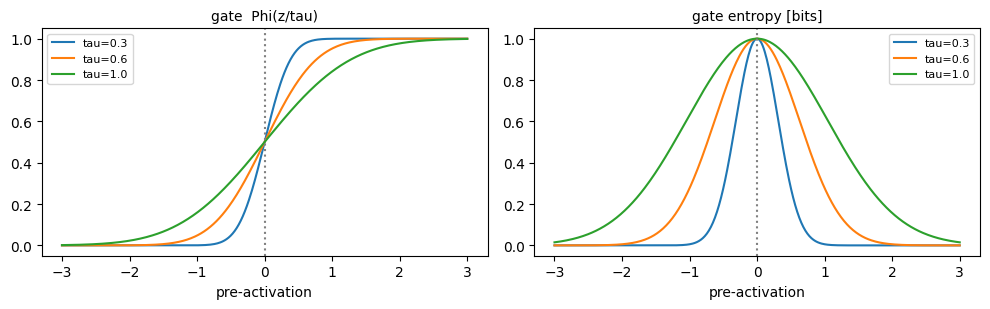

In [2]:
from spx.entropy_flow import binary_gate_entropy
from spx.soft_adjoint import normal_cdf

zz = torch.linspace(-3, 3, 400)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
for tau in (0.3, 0.6, 1.0):
    g = normal_cdf(zz / tau)
    ax[0].plot(zz, g, label=f'tau={tau}')
    ax[1].plot(zz, binary_gate_entropy(g), label=f'tau={tau}')
ax[0].set_title('gate  Phi(z/tau)', fontsize=10)
ax[1].set_title('gate entropy [bits]', fontsize=10)
for a in ax:
    a.set_xlabel('pre-activation'); a.axvline(0, ls=':', c='grey'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Is there anything there on a real network???

If every gate were decided, `S` would be flat and the whole thing returns zero.
Worth checking before going further.

One gotcha: torchvision's `Bottleneck` calls a single `self.relu` **three**
times per forward, so gates have to be counted by call site. Counting by module
gives 17 instead of 49.

50 gates, 9,809,408 units


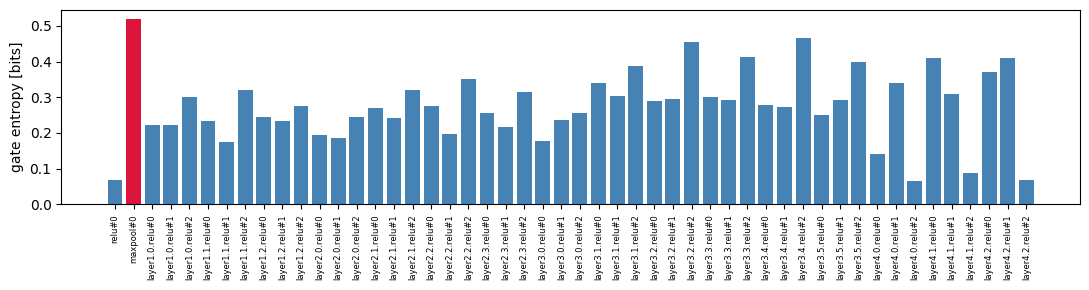

,gate,units,entropy_bits
1,maxpool#0,200704,0.519
37,layer3.4.relu#2,200704,0.467
31,layer3.2.relu#2,200704,0.455
43,layer4.0.relu#2,100352,0.066
0,relu#0,802816,0.068
49,layer4.2.relu#2,100352,0.069


In [3]:
from spx.entropy_flow import gate_entropy_report

names, means, units = gate_entropy_report(bundle.soft, X)
gates = pd.DataFrame({'gate': names, 'units': units,
                      'entropy_bits': means.mean(0).numpy()})
print(f'{len(gates)} gates, {gates.units.sum():,} units')

fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(range(len(gates)), gates.entropy_bits,
       color=['crimson' if 'maxpool' in g else 'steelblue' for g in gates.gate])
ax.set_xticks(range(len(gates)), gates.gate, rotation=90, fontsize=6)
ax.set_ylabel('gate entropy [bits]')
plt.tight_layout(); plt.show()

pd.concat([gates.nlargest(3, 'entropy_bits'), gates.nsmallest(3, 'entropy_bits')]).round(3)

Median around 0.27 bits, range 0.07-0.52. Two things fall out for free:

* The most undecided thing in the network is the **MaxPool** gate (red). That is
  independently the one place where the `tau -> 0` limit provably fails to
  recover the gradient a softmax over a tied window is uniform for every
  `tau`. Two unrelated routes to the same layer.
* Indecision sits in `layer3`. The stem and the last ReLU of each `layer4` block
  are the most decided.

## The functional and the map

```
S(x) = sum over gates of  mean( entropy of that gate )
```

then `dS/dx` **through the unchanged soft-adjoint backward pass**. Entropies are
normalised to `[0,1]` so a 9-way pooling gate and a 2-way ReLU gate are on one
scale, and layers are weighted equally so the stem (802k units) doesn't drown
out `layer4` (100k).

Two variants: `EntropyFlow` weights all units equally, `ClassEntropyFlow`
weights each gate by how much of class `c`'s pullback mass flows through it
"where does the evidence for c pass through machinery that hasn't decided".

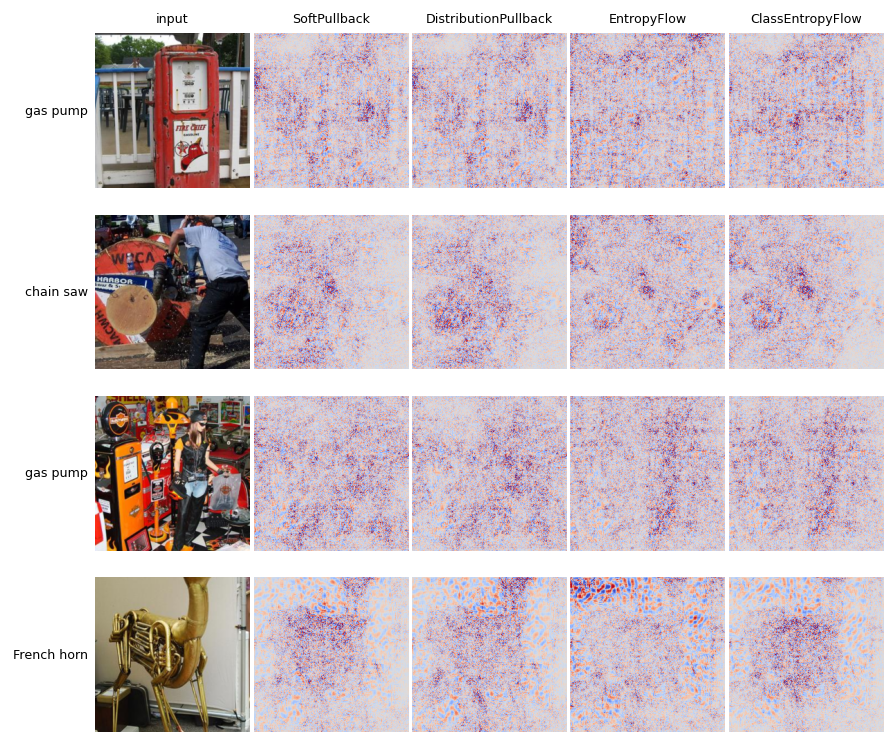

In [4]:
from spx.dossier import attributions_for

A = attributions_for(bundle, X, Y, {
    'SoftPullback': {},                  # class channel
    'DistributionPullback': {'p_floor': 1e-3, 'eps': 1e-3},
    'EntropyFlow': {},                   # uncertainty channel
    'ClassEntropyFlow': {},
})
show_maps(X, A, titles=titles)
plt.show()

## Does the direction do what it says?

Step along `+dS/dx` and gate entropy should go up; along `-dS/dx`, down. If it
doesn't, nothing downstream matters.

In [5]:
from spx.entropy_flow import EntropyFlow, GateEntropyProbe
from spx.explainers import _l2norm

def total_entropy(inp):
    with GateEntropyProbe(bundle.soft) as probe:
        with torch.no_grad():
            bundle.soft(inp)
        return probe.functional()

ef = EntropyFlow(bundle)
rows = []
for sign, label in [(+1.0, 'ascend'), (-1.0, 'descend')]:
    xt = X.clone()
    S0 = total_entropy(xt)
    for step in range(3):
        nu = ef.attribute(xt, Y)
        xt = bundle.project(xt + sign * 20.0 * _l2norm(nu))
        S = total_entropy(xt)
        rows.append({'direction': label, 'step': step + 1,
                     'dS': float((S - S0).mean()),
                     'images moving the right way': f'{int(((S - S0) * sign > 0).sum())}/{len(X)}'})
pd.DataFrame(rows).round(4)

,direction,step,dS,images moving the right way
0,ascend,1,0.0208,4/4
1,ascend,2,0.0302,4/4
2,ascend,3,0.0345,4/4
3,descend,1,-0.0187,4/4
4,descend,2,-0.0324,4/4
5,descend,3,-0.0425,4/4


It does, on every image and every step not just on average. :)

## The point: it's a different channel

If this were just a re-weighting of the class explanation it wouldn't be worth
a separate method. So: compare it against the class-conditional maps, and
compare *that* against how similar those maps are to each other.

In [6]:
import torch.nn.functional as F
from spx.entropy_flow import ClassEntropyFlow
from spx.explainers import DistributionPullback, MarginPullback, SoftPullback

def cos(a, b):
    return float(F.cosine_similarity(a.flatten(1), b.flatten(1), dim=1).mean())

a_ef = ef.attribute(X, Y).detach()
maps = {'SoftPullback': SoftPullback(bundle).attribute(X, Y).detach(),
        'DistributionPullback': DistributionPullback(bundle, p_floor=1e-3, eps=1e-3).attribute(X, Y).detach(),
        'MarginPullback': MarginPullback(bundle, k=8).attribute(X, Y).detach(),
        'ClassEntropyFlow': ClassEntropyFlow(bundle).attribute(X, Y).detach()}

print('EntropyFlow vs the class-conditional maps:')
for name, a in maps.items():
    print(f'  cos = {cos(a_ef, a):+.3f}   {name}')

print('\nfor scale -- how similar those maps are to each other:')
for name in ['DistributionPullback', 'MarginPullback']:
    print(f'  cos = {cos(maps[name], maps["SoftPullback"]):+.3f}   {name} vs SoftPullback')

EntropyFlow vs the class-conditional maps:
  cos = -0.045   SoftPullback
  cos = +0.052   DistributionPullback
  cos = -0.069   MarginPullback
  cos = +0.863   ClassEntropyFlow

for scale -- how similar those maps are to each other:
  cos = +0.855   DistributionPullback vs SoftPullback
  cos = +0.871   MarginPullback vs SoftPullback


The class-conditional methods sit at ok 0.85 against each other. Entropy-Flow is
at ok 0 against all of them it's pointing somewhere else in the image.

`ClassEntropyFlow` at ok 0.9 against `EntropyFlow` is what you'd want: clearly
related to the class-agnostic version, still near-orthogonal to the class
channel.